## Data Calibration

### Estimating Drift and Volatility

##### We estimate annualized drift and volatility from historical daily log returns of SPY

In [1]:
# importing tools 
import yfinance as yf
import numpy as np
import pandas as pd

In [47]:
# 1. Fetching the Data
# We use 'Adj Close' to account for stock splits and dividend distributions.
ticker = "SPY" # The S&P 500 ETF (our stable baseline)
data = yf.download(ticker, start="2018-01-01", end="2024-01-01")
# selecting the closing price 
prices = data['Close']

[*********************100%***********************]  1 of 1 completed


In [48]:
# 2. Vectorized Calculation of Log Returns
# Why log returns? Because they are time-additive and theoretically normally distributed
# which aligns perfectly with the Wiener process (dW_t) in our GBM equation.
# Notice there are no 'for' loops here. numpy handles the entire array at once.
log_returns = np.log(prices / prices.shift(1)).dropna()

# 3. Estimating Parameters
# We calculate the daily mean and standard deviation, then annualize them.
# There are typically 252 trading days in a year.
# Note: Volatility scales with the square root of time, not linearly.
daily_mu = log_returns.mean()
daily_sigma = log_returns.std()

annual_mu = daily_mu * 252
annual_sigma = daily_sigma * np.sqrt(252)

# annual_ii is a multi-indexed array so i extracted the values out 
print(f"Annualized Drift (\u03bc): {annual_mu.values[0]:.4f}") 
print(f"Annualized Volatility (\u03c3): {annual_sigma.values[0]:.4f}")

Annualized Drift (μ): 0.1121
Annualized Volatility (σ): 0.2047


## Vectorized GBM

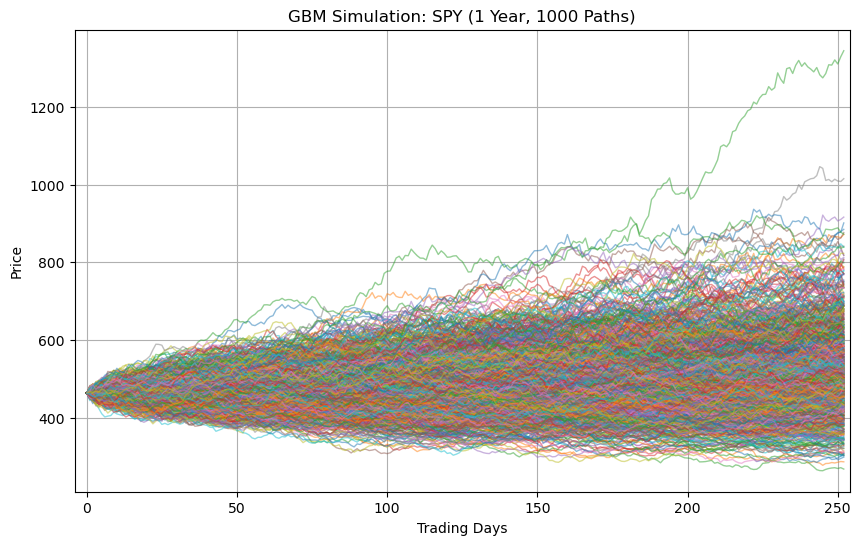

In [52]:
import matplotlib.pyplot as plt

# 1. Setup Parameters (Using your calibrated data)
mu = 0.1121
sigma = 0.2047
S0 = prices.iloc[-1] # The last known price from your dataset
T = 1.0              # 1 year into the future
dt = 1/252           # Daily time steps
N = int(T / dt)      # Number of steps (252)
M = 1000             # Number of simulated paths

# 2. The Vectorized Engine
# Generate random shocks Z ~ N(0,1) for every path and every day simultaneously.
# The shape is (Days, Paths) -> (252, 1000)
Z = np.random.standard_normal((N, M))

# Calculate the deterministic drift and the random shock components
drift = (mu - 0.5 * sigma**2) * dt
shock = sigma * np.sqrt(dt) * Z

# Calculate daily log returns. 
daily_returns = drift + shock

# np.cumsum adds up the returns across the time axis (axis=0) day by day
cumulative_returns = np.cumsum(daily_returns, axis=0)

# Exponentiate to convert cumulative log returns back to actual prices
price_paths = S0.values[0] * np.exp(cumulative_returns)

# Prepend the initial price (Day 0) to the top of the array
S0_array = np.full((1, M), S0)
price_paths = np.vstack((S0_array, price_paths))

# 3. Visualization
plt.figure(figsize=(10, 6))
# We plot the first 100 paths so the graph isn't entirely blocked out
plt.plot(price_paths[:, :], lw=1, alpha=0.5)
plt.title("GBM Simulation: SPY (1 Year, 1000 Paths)")
plt.xlim(-4,254)
plt.xlabel("Trading Days")
plt.ylabel("Price")
plt.grid(True)
plt.savefig("GBM_Simulation.png", dpi=300, bbox_inches='tight')
plt.show()

## Model Validation

### Histogram - Distribution

Simulation Skewness: 0.9811 (Expected > 0)
Simulation Excess Kurtosis: 3.1789


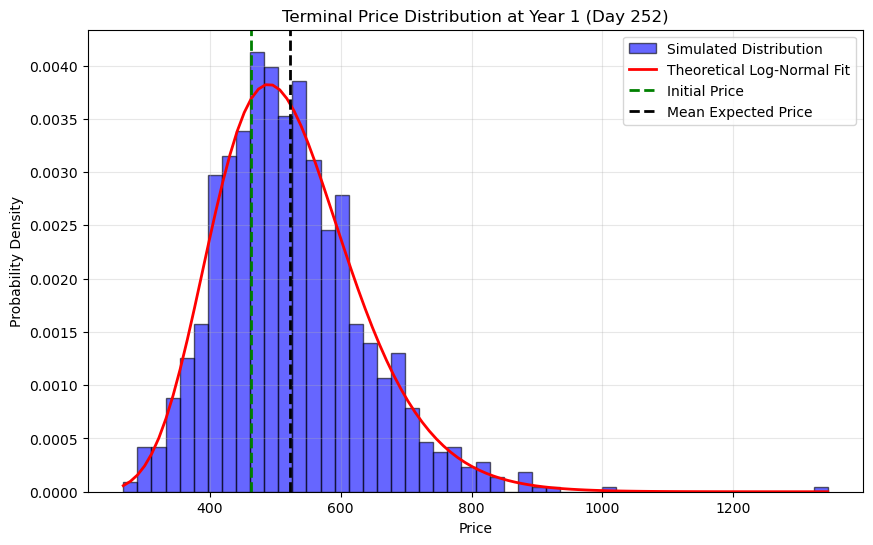

In [53]:
import scipy.stats as stats

# 1. Extract the terminal prices (the final row of our simulation matrix)
terminal_prices = price_paths[-1, :]

# 2. Calculate Statistical Moments
# A standard normal distribution has a skew of 0 and an excess kurtosis of 0.
skewness = stats.skew(terminal_prices)
excess_kurtosis = stats.kurtosis(terminal_prices)

print(f"Simulation Skewness: {skewness:.4f} (Expected > 0)")
print(f"Simulation Excess Kurtosis: {excess_kurtosis:.4f}")

# 3. Visualization: Histogram vs. Theoretical Fit
plt.figure(figsize=(10, 6))

# Plot the empirical distribution of our simulated prices
plt.hist(terminal_prices, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black', label='Simulated Distribution')

# Fit and overlay a theoretical log-normal curve
shape, loc, scale = stats.lognorm.fit(terminal_prices, floc=0)
x = np.linspace(min(terminal_prices), max(terminal_prices), 100)
pdf = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical Log-Normal Fit')

# Add markers for initial and mean prices
plt.axvline(S0.values[0], color='green', linestyle='dashed', linewidth=2, label=f'Initial Price')
plt.axvline(np.mean(terminal_prices), color='black', linestyle='dashed', linewidth=2, label=f'Mean Expected Price')

plt.title("Terminal Price Distribution at Year 1 (Day 252)")
plt.xlabel("Price")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("Terminal_Price_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

### Q-Q Plot

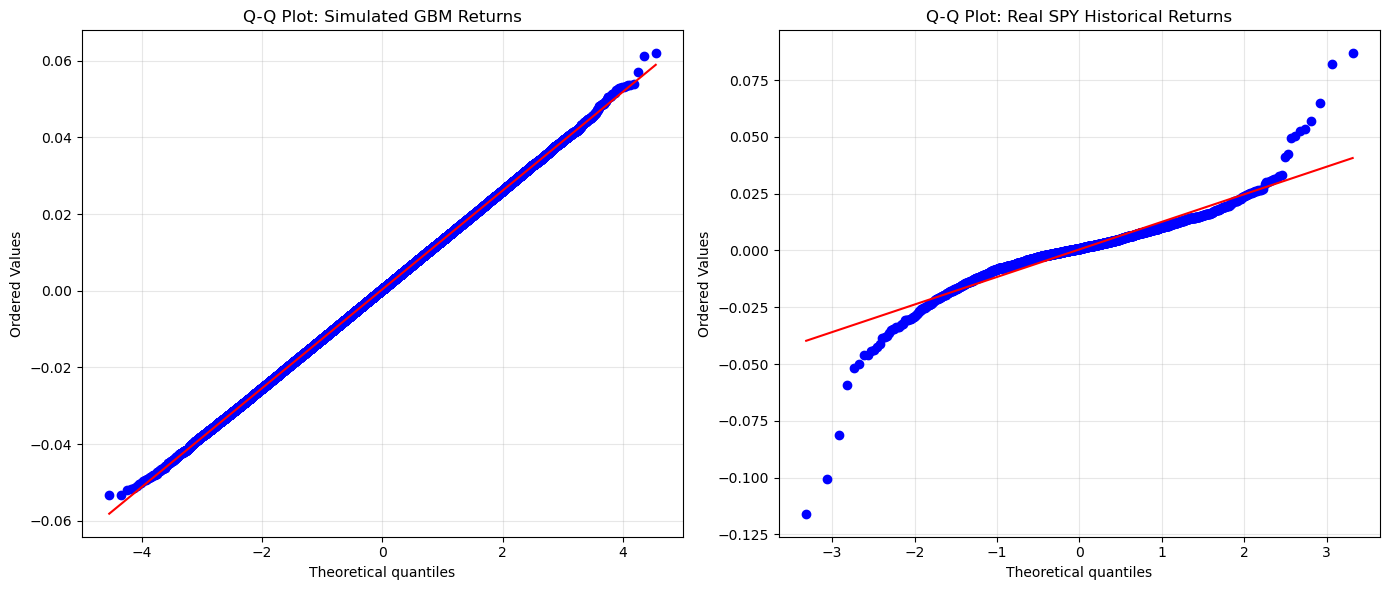

Simulated Returns Excess Kurtosis: -0.0043 (Expected ~ 0)
Real Historical Returns Excess Kurtosis: 11.8850


In [54]:
# Create a side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Q-Q Plot of SIMULATED daily log returns
# We flatten our simulated daily returns matrix to test the whole population
simulated_returns = daily_returns.flatten()
stats.probplot(simulated_returns, dist="norm", plot=ax[0])
ax[0].set_title("Q-Q Plot: Simulated GBM Returns")
ax[0].grid(True, alpha=0.3)

# 2. Q-Q Plot of ACTUAL historical SPY log returns
stats.probplot(log_returns.values.flatten(), dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot: Real SPY Historical Returns")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("QQ_Plot_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Print the kurtosis of the RETURNS (not the prices)
print(f"Simulated Returns Excess Kurtosis: {stats.kurtosis(simulated_returns):.4f} (Expected ~ 0)")
print(f"Real Historical Returns Excess Kurtosis: {stats.kurtosis(log_returns)[0]:.4f}")